#Notebook: Perceptrón
**Autora:** Yadsiri Vazquez\
**Materia:** Clasificación inteligente de datos  


---

## 1.1- Fundamentos de la técnica

El perceptrón es el modelo más simple de una red neuronal artificial. Fue propuesto por Frank Rosenblatt en 1958.  
Su objetivo es clasificar patrones linealmente separables, es decir, aquellos que pueden separarse mediante una línea recta (en 2D), un plano (en 3D) o un hiperplano (en dimensiones mayores).  

El algoritmo del Perceptrón ajusta los pesos de las entradas de manera iterativa para minimizar los errores de clasificación, usando una regla de aprendizaje supervisado.

El proceso general:
1. Inicializa pesos aleatorios.
2. Calcula la salida del modelo.
3. Actualiza los pesos si la salida no coincide con la esperada.
4. Repite hasta que no haya errores o se alcance un número máximo de iteraciones.

##1.2- Modelo Matemático del Perceptrón

El modelo del perceptrón se define matemáticamente como:

y = f(w * x + b)

Donde:

x = [X₁, X₂, ..., Xₙ] son las entradas.

w = [W₁, W₂, ..., Wₙ] son los pesos.

b es el bias o término de sesgo.

f es una función de activación, usualmente la función escalón (step function):

f(z) =
1 si z ≥ 0
0 si z < 0

La ecuación principal:

y = f(w * x + b)

Representa el proceso de decisión del perceptrón, donde:

El producto punto w * x = Σ (wᵢ * xᵢ) combina las entradas ponderadas.

El bias b ajusta el umbral de activación, desplazando la frontera de decisión.
- Función de activación f: determina la salida binaria (0 o 1).


##1.3- Descripción de la librería y funciones en Python (Scikit-learn)

Para implementar el Perceptrón utilizaremos la librería scikit-learn.

###Clases principales:
- sklearn.linear_model.Perceptron: Implementa el algoritmo del perceptrón clásico, usado para clasificación binaria linealmente separable.
- make_classification: Esta función genera un conjunto de datos artificiales para problemas de clasificación supervisada. En este caso, se usó para crear un dataset linealmente separable con dos características (features).
- train_test_split(): Divide los datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo sin sesgos.
- fit(X, y): Entrena el modelo.
- predict(X): Realiza predicciones sobre nuevos datos, utilizando los pesos aprendidos durante el entrenamiento.
- accuracy_score(): Calcula el porcentaje de predicciones correctas respecto al total de muestras.

Otras librerías que utilizaremos:
- numpy: Para manejo de arreglos numéricos.
- matplotlib: Para visualizar resultados.
- sklearn.datasets: Para generar datos de prueba.
- sklearn.metrics: Para calcular métricas de desempeño.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

###1.4.1- Feature Engineering

Generaremos un conjunto de datos sintético con make_classification que tenga 2 características y 2 clases.
Estas características representarán las "señales de entrada" al perceptrón.


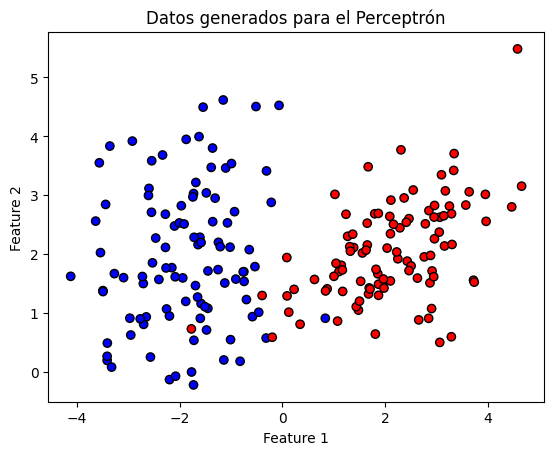

In [23]:
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, class_sep=2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.title("Datos generados para el Perceptrón")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

###1.4.2 Model Selection

El Perceptrón es adecuado porque el conjunto de datos es linealmente separable.  
En este caso, buscamos un clasificador lineal que aprenda una frontera de decisión simple.


###1.4.3 Model Training
Entrenaremos el modelo con una parte de los datos (70% entrenamiento, 30% prueba).


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

##
model = Perceptron(max_iter=2000, eta0=0.01, random_state=42) #Creamos
model.fit(X_train, y_train) #Entrenamos

print("Entrenamiento completado.")

Entrenamiento completado.


### 1.4.4 Prediction
Probamos el modelo con algunos datos de prueba y creamos una función para visualizar las clasificaciones.

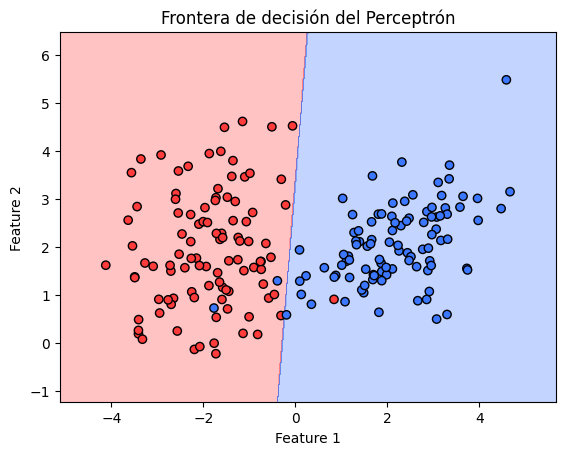

In [25]:
def plot_decision_boundary(model, X, y): #modelo ya entrenado con los datos de entrada X y las etiquetas reales y
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    pts = np.c_[xx.ravel(), yy.ravel()] #combina los valores X e Y de la malla en pares de coordenadas
    Z = model.predict(pts) # el modelo clasifica cada punto del plano según lo que aprendió

    cmap = ListedColormap(['#ff3b3b', '#3b77ff'])
    plt.contourf(xx, yy, Z.reshape(xx.shape), alpha=0.3, cmap=cmap)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolor='k')
    plt.title("Frontera de decisión del Perceptrón")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(model, X, y)

###1.4.5 Model Evaluation
Calculamos la Accuracy (exactitud) del modelo y explicamos brevemente el resultado.
- Accuracy = número de predicciones correctas / total de predicciones
- Un valor cercano a 1 indica que el modelo clasificó correctamente casi todos los patrones.

In [26]:
#Usa el modelo ya entrenado (model) para hacer predicciones sobre los datos que nunca ha visto antes (X_test)
y_pred = model.predict(X_test)#El resultado, un vector con las etiquetas predichas
accuracy = accuracy_score(y_test, y_pred)#calcula la precision del modelo comparando las predicciones con las etiquetas reales
print(f"Exactitud del modelo: {accuracy:.2f}")

Exactitud del modelo: 0.98


## 2. Interpretación y ejecución

Este notebook puede ejecutarse sin errores tanto en Jupyter como en Google Colab, ya que solo requiere las librerías:  
numpy, `matplotlib, y scikit-learn.

Para ejecutarlo en Colab:
1. Abre [https://colab.research.google.com](https://colab.research.google.com)
2. Sube este notebook o crea uno nuevo.
3. Ejecuta las celdas secuencialmente.

##3. Referencias Bibliográficas

- El poder del Cómputo. (2022, 21 junio). El Perceptrón paso a paso en Python || Programación en Python [Vídeo]. YouTube. https://www.youtube.com/watch?v=6W-p4qziSW8  
- Rosebrock, A. (2021, 12 mayo). Implementing the Perceptron Neural Network with Python - PyImageSearch. PyImageSearch. https://pyimagesearch.com/2021/05/06/implementing-the-perceptron-neural-network-with-python/
- Scikit-learn Documentation: [https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html)
- Joseavinatecmm. (s. f.). GitHub - joseavinatecmm/IDC: Intellingent Data Classification. GitHub. https://github.com/joseavinatecmm/IDC.git
- Chat GPT.
